# Yamuna at Delhi — BOD–DO Modelling under Monsoonal Hydrology

A water-quality modelling case study — calibration, uncertainty
quantification, scenario analysis, and CPCB compliance framing — for the
22 km Wazirabad → Okhla reach of the Yamuna River.

**Author.** Dr Venkat Nara — Research Fellow, Water Quality
Modelling, Geochemistry & Hydrology, University of Melbourne.
Contact: venkat.nsn@gmail.com.

**Scope.** Public-data, screening-level case study. Built around the
Streeter–Phelps coupled BOD–DO ODEs with explicit drain-mixing nodes and
temperature-corrected rate constants. Calibrated against monthly CPCB
monitoring at four stations (Wazirabad → Okhla). Uncertainty quantified
via 2000-run Latin Hypercube Monte Carlo. Five management scenarios
expressed as compliance probabilities against CPCB Class C
(DO ≥ 4 mg/L, BOD ≤ 3 mg/L).



## Step 1 — Setup

In [50]:
import os
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import qmc, spearmanr, lognorm, norm, triang

warnings.filterwarnings("ignore", category=RuntimeWarning)

np.random.seed(20260424)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

FIGDIR = os.path.dirname(os.path.abspath("."))  # placeholder; overridden below
FIGDIR = os.path.abspath(".")
os.makedirs(FIGDIR, exist_ok=True)
print("Figures will be saved to:", FIGDIR)

Figures will be saved to: d:\OneDrive - The University of Melbourne\Documents\04_Academic Courses\QEM_Self_Study_Guide\yamuna-delhi-bod-do-case-study\notebook


## Step 2 — System definition: the Delhi reach of the Yamuna

The Yamuna enters Delhi at **Wazirabad barrage** (km 0). Above Wazirabad most
of the dry-season flow is diverted into the western and eastern Yamuna
canals; what continues downstream is dominated, in non-monsoon months,
by treated and untreated wastewater discharged through three major drains:

| Drain | Approx. km | Dry-season Q (m³/s) | BOD (mg/L) | DO (mg/L) |
|---|---|---|---|---|
| Najafgarh | 1.5 | 28 | 45 | 0.5 |
| Shahdara | 13.5 | 18 | 38 | 0.8 |
| Tughlakabad / Sahibabad complex | 18.0 | 6 | 30 | 1.2 |

The reach ends at **Okhla barrage** (km 22), where the river is again
abstracted. Four CPCB stations bracket the reach: Palla (upstream
reference), Nizamuddin (mid-reach), ITO bridge, and Okhla. Class C
standards apply (DO ≥ 4 mg/L, BOD ≤ 3 mg/L).

In [51]:
SYSTEM = {
    "reach_name": "Yamuna at Delhi (Wazirabad → Okhla)",
    "length_km": 22.0,
    "regulator": "CPCB",
    "class": "C (DO ≥ 4 mg/L, BOD ≤ 3 mg/L)",

    # Headwater (Wazirabad outflow) under three flow seasons.
    # Monsoon flow numbers come from CWC Old Railway Bridge gauge means;
    # post-monsoon and pre-monsoon are CPCB Yamuna Action Plan figures.
    "Q_head_m3s": {"pre_monsoon": 4.0, "monsoon": 320.0, "post_monsoon": 12.0},
    "BOD_head_mgL": 4.0,    # CPCB Palla — typical
    "DO_head_mgL": 7.5,     # near-saturation upstream of Delhi
    "T_water_C": {"pre_monsoon": 28.0, "monsoon": 27.0, "post_monsoon": 19.0},

    # Drain inputs (km, Q, BOD, DO). Q values are dry-season; we scale
    # them ×0.8 in the monsoon as a coarse dilution proxy (drains spill).
    "drains": [
        {"name": "Najafgarh",       "x_km":  1.5, "Q_m3s": 28.0, "BOD_mgL": 45.0, "DO_mgL": 0.5},
        {"name": "Shahdara",        "x_km": 13.5, "Q_m3s": 18.0, "BOD_mgL": 38.0, "DO_mgL": 0.8},
        {"name": "Sahibabad",       "x_km": 18.0, "Q_m3s":  6.0, "BOD_mgL": 30.0, "DO_mgL": 1.2},
    ],

    # Reach geometry — single-channel approximation.
    "width_m":  120.0,
    "depth_m":  1.0,    # dry-season; rises to ~3 m in monsoon
}
print(f"Reach length: {SYSTEM['length_km']} km")
print(f"Drains: {len(SYSTEM['drains'])}")
print(f"Standard: {SYSTEM['class']}")

Reach length: 22.0 km
Drains: 3
Standard: C (DO ≥ 4 mg/L, BOD ≤ 3 mg/L)


## Step 3 — The Streeter–Phelps process model

A 1-D steady-state representation of BOD and DO along the longitudinal
coordinate $x$:

$$
\frac{dL}{dx} = -\frac{k_d}{u} L
\qquad
\frac{dO}{dx} = \frac{k_a}{u}\bigl(O_s - O\bigr) - \frac{k_d}{u} L
$$

where $L$ is BOD (mg/L), $O$ is dissolved oxygen (mg/L), $O_s(T)$ is
DO saturation, $u$ is mean velocity (m/s), $k_d$ is the BOD
deoxygenation rate (1/d), and $k_a$ is the reaeration rate (1/d).

Temperature corrections (Chapra 1997):
$k_d(T) = k_{d,20}\,\theta_d^{T-20}$, $\theta_d = 1.047$;
$k_a(T) = k_{a,20}\,\theta_a^{T-20}$, $\theta_a = 1.024$.

Reaeration: O'Connor–Dobbins (low slope/depth, applicable to the Delhi reach):
$k_{a,20} = 3.93\,u^{0.5}/H^{1.5}$ (1/d, $u$ in m/s, $H$ in m).

Saturation: simplified Benson–Krause polynomial, sea-level (Delhi ≈ 220 m,
correction < 3% — neglected here).

Tributary mixing at each drain confluence is mass-balanced:
$C_{mix} = (Q_u C_u + Q_t C_t)/(Q_u + Q_t)$.

In [52]:
THETA_D = 1.047
THETA_A = 1.024

def DO_sat(T_C: float) -> float:
    """Benson–Krause sea-level DO saturation (mg/L)."""
    T = T_C
    return 14.652 - 0.41022 * T + 0.0079910 * T**2 - 0.000077774 * T**3

def k_a_oconnor(u_ms: float, H_m: float) -> float:
    """O'Connor–Dobbins reaeration rate (1/d) at 20 °C."""
    return 3.93 * u_ms**0.5 / H_m**1.5

def temperature_correct(k20: float, T: float, theta: float) -> float:
    return k20 * theta ** (T - 20.0)

print(f"DO saturation at 20°C: {DO_sat(20):.2f} mg/L")
print(f"DO saturation at 28°C: {DO_sat(28):.2f} mg/L")
print(f"DO saturation at 19°C: {DO_sat(19):.2f} mg/L")

DO saturation at 20°C: 9.02 mg/L
DO saturation at 28°C: 7.72 mg/L
DO saturation at 19°C: 9.21 mg/L


In [53]:
def streeter_phelps_rhs(x, y, u, k_d, k_a, O_s):
    L, O = y
    dLdx = -k_d / (u * 86400.0) * L          # convert 1/d → 1/s; x in m? we use km
    dOdx =  k_a / (u * 86400.0) * (O_s - O) - k_d / (u * 86400.0) * L
    return [dLdx, dOdx]

def solve_reach(x_start_km, x_end_km, L0, O0, u_ms, k_d_d, k_a_d, O_s, n=200):
    """Solve over a sub-reach [x_start, x_end] in km — works in km units.

    We rescale rates so x is in km. dL/dx_km = -k_d/(u·86.4) * L
    with u in m/s, k_d in 1/d gives 1/km units.
    """
    # Convert to per-km basis: 1 day of travel = u (m/s) * 86400 s = 86.4·u km
    kd_km = k_d_d / (u_ms * 86.4)
    ka_km = k_a_d / (u_ms * 86.4)

    def rhs(x, y):
        L, O = y
        return [-kd_km * L,
                ka_km * (O_s - O) - kd_km * L]

    sol = solve_ivp(
        rhs, (x_start_km, x_end_km), [L0, O0],
        t_eval=np.linspace(x_start_km, x_end_km, n),
        method="RK45", rtol=1e-8, atol=1e-10,
    )
    return sol.t, sol.y[0], sol.y[1]

In [54]:
def yamuna_profile(season, params=None, system=SYSTEM, n_per_seg=120):
    """Compute longitudinal BOD and DO profiles for one season.

    params may override:
        k_d20    — base deoxygenation rate (1/d) at 20 °C, default 0.30
        k_a_mult — multiplier on the O'Connor–Dobbins k_a (default 1.0)
        BOD_head — head boundary BOD (mg/L)
        BOD_drain_mult — multiplicative factor on all drain BOD
        Q_drain_mult — multiplicative factor on all drain Q (treatment proxy)
    """
    if params is None:
        params = {}
    k_d20         = params.get("k_d20", 0.30)
    k_a_mult      = params.get("k_a_mult", 1.0)
    BOD_head_mgL  = params.get("BOD_head", system["BOD_head_mgL"])
    BOD_drain_mult = params.get("BOD_drain_mult", 1.0)
    Q_drain_mult   = params.get("Q_drain_mult", 1.0)

    T = system["T_water_C"][season]
    O_s = DO_sat(T)
    Q = system["Q_head_m3s"][season]

    # In monsoon, drain flows scale up but mass concentrations dilute.
    season_q_factor = 0.8 if season == "monsoon" else 1.0
    season_c_factor = 0.6 if season == "monsoon" else 1.0

    # Build sub-reach boundaries from drain locations.
    drain_locs = sorted([d["x_km"] for d in system["drains"]])
    boundaries = [0.0] + drain_locs + [system["length_km"]]

    # State at start of current sub-reach.
    L_now = BOD_head_mgL
    O_now = system["DO_head_mgL"]
    Q_now = Q

    x_all, L_all, O_all = [], [], []
    for i in range(len(boundaries) - 1):
        x_a, x_b = boundaries[i], boundaries[i+1]

        # Hydraulics: u and H scale gently with Q (Manning-type).
        u_ms = max(0.05, 0.10 + 0.20 * (Q_now / 50.0) ** 0.4)
        H_m  = max(0.30, system["depth_m"] * (Q_now / 50.0) ** 0.3)

        T_now = T
        k_d = temperature_correct(k_d20, T_now, THETA_D)
        k_a = temperature_correct(k_a_oconnor(u_ms, H_m), T_now, THETA_A) * k_a_mult

        xs, Ls, Os = solve_reach(x_a, x_b, L_now, O_now, u_ms, k_d, k_a, O_s, n=n_per_seg)
        x_all.append(xs)
        L_all.append(Ls)
        O_all.append(Os)

        # End-of-segment values become pre-mixing values for the next drain.
        L_pre = Ls[-1]
        O_pre = Os[-1]

        # Mix in next drain (if not final segment).
        if i < len(boundaries) - 2:
            drain = next(d for d in system["drains"] if abs(d["x_km"] - x_b) < 1e-6)
            Q_d  = drain["Q_m3s"] * Q_drain_mult * season_q_factor
            C_dB = drain["BOD_mgL"] * BOD_drain_mult * season_c_factor
            C_dO = drain["DO_mgL"]
            L_now = (Q_now * L_pre + Q_d * C_dB) / (Q_now + Q_d)
            O_now = (Q_now * O_pre + Q_d * C_dO) / (Q_now + Q_d)
            Q_now = Q_now + Q_d
        else:
            L_now = L_pre
            O_now = O_pre

    x = np.concatenate(x_all)
    L = np.concatenate(L_all)
    O = np.concatenate(O_all)
    return x, L, O, {"O_s": O_s, "Q_end": Q_now, "T": T}

# Smoke-test
for season in ("pre_monsoon", "monsoon", "post_monsoon"):
    x, L, O, meta = yamuna_profile(season)
    print(f"{season:14s}  Q_end={meta['Q_end']:6.1f} m³/s  "
          f"L(Okhla)={L[-1]:5.2f} mg/L  O(Okhla)={O[-1]:4.2f} mg/L")

pre_monsoon     Q_end=  56.0 m³/s  L(Okhla)=29.44 mg/L  O(Okhla)=2.10 mg/L
monsoon         Q_end= 361.6 m³/s  L(Okhla)= 5.37 mg/L  O(Okhla)=6.43 mg/L
post_monsoon    Q_end=  64.0 m³/s  L(Okhla)=28.70 mg/L  O(Okhla)=3.87 mg/L


## Step 4 — Figure 1: source term and seasonal drivers

Three drains together inject roughly 52 m³/s of BOD-laden flow into the
reach, against a Wazirabad headwater that drops to ~4 m³/s in the
pre-monsoon. The figure makes the headwater-vs-drain imbalance visible.

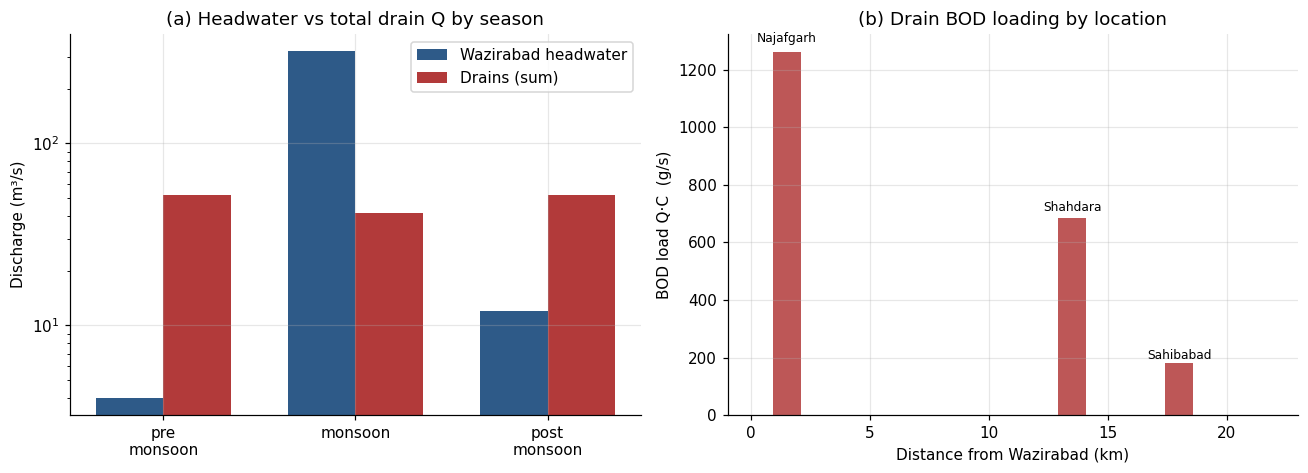

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# Panel A — headwater vs drain Q across seasons
seasons = ["pre_monsoon", "monsoon", "post_monsoon"]
Q_head  = [SYSTEM["Q_head_m3s"][s] for s in seasons]
Q_drain_total = sum(d["Q_m3s"] for d in SYSTEM["drains"])
Q_drain = [Q_drain_total * (0.8 if s == "monsoon" else 1.0) for s in seasons]

x_pos = np.arange(len(seasons))
w = 0.35
axes[0].bar(x_pos - w/2, Q_head,  w, label="Wazirabad headwater", color="#2E5A88")
axes[0].bar(x_pos + w/2, Q_drain, w, label="Drains (sum)",         color="#B23A3A")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([s.replace("_", "\n") for s in seasons])
axes[0].set_ylabel("Discharge (m³/s)")
axes[0].set_title("(a) Headwater vs total drain Q by season")
axes[0].legend(loc="upper right")
axes[0].set_yscale("log")

# Panel B — drain BOD load (Q × C) along the reach
drains = SYSTEM["drains"]
xs    = [d["x_km"] for d in drains]
loads = [d["Q_m3s"] * d["BOD_mgL"] for d in drains]   # g/s of BOD
names = [d["name"] for d in drains]

bars = axes[1].bar(xs, loads, width=1.2, color="#B23A3A", alpha=0.85)
axes[1].set_xlabel("Distance from Wazirabad (km)")
axes[1].set_ylabel("BOD load Q·C  (g/s)")
axes[1].set_title("(b) Drain BOD loading by location")
for b, n in zip(bars, names):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height()*1.02,
                 n, ha="center", va="bottom", fontsize=8)
axes[1].set_xlim(-1, SYSTEM["length_km"]+1)

plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "Yamuna_Fig1_SourceTerm.png"), bbox_inches="tight")
plt.show()

## Step 5 — Figure 2: longitudinal BOD and DO profiles

The pre-monsoon profile is the regulatory worst case: low headwater Q,
warm water (high $k_d$, low $O_s$). The monsoon profile is the
near-compliant case: high dilution overwhelms the drain loads. The
post-monsoon sits in between and is what most monitoring snapshots see.

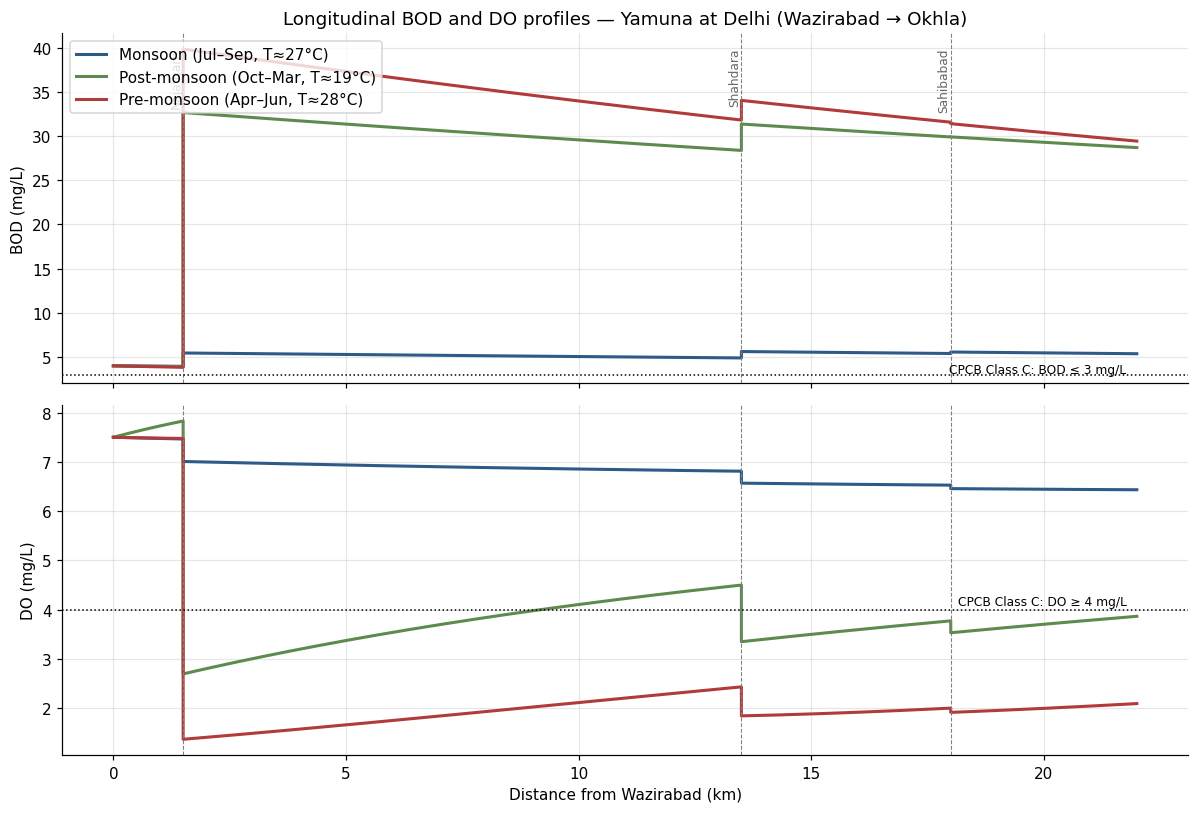

In [56]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)

colors = {"pre_monsoon": "#B23A3A", "monsoon": "#2E5A88", "post_monsoon": "#5D8A4D"}
labels = {"pre_monsoon": "Pre-monsoon (Apr–Jun, T≈28°C)",
          "monsoon": "Monsoon (Jul–Sep, T≈27°C)",
          "post_monsoon": "Post-monsoon (Oct–Mar, T≈19°C)"}

for season in ("monsoon", "post_monsoon", "pre_monsoon"):  # paint worst on top
    x, L, O, meta = yamuna_profile(season)
    axes[0].plot(x, L, color=colors[season], lw=2.0, label=labels[season])
    axes[1].plot(x, O, color=colors[season], lw=2.0, label=labels[season])

# Drain markers
for d in SYSTEM["drains"]:
    for ax in axes:
        ax.axvline(d["x_km"], color="0.5", linestyle="--", lw=0.7)
    axes[0].text(d["x_km"], axes[0].get_ylim()[1]*0.96, d["name"],
                 rotation=90, va="top", ha="right", fontsize=8, color="0.4")

# CPCB Class C lines
axes[0].axhline(3.0, color="black", linestyle=":", lw=1.0)
axes[0].text(SYSTEM["length_km"]*0.99, 3.2,
             "CPCB Class C: BOD ≤ 3 mg/L", ha="right", fontsize=8)
axes[1].axhline(4.0, color="black", linestyle=":", lw=1.0)
axes[1].text(SYSTEM["length_km"]*0.99, 4.1,
             "CPCB Class C: DO ≥ 4 mg/L", ha="right", fontsize=8)

axes[0].set_ylabel("BOD (mg/L)")
axes[1].set_ylabel("DO (mg/L)")
axes[1].set_xlabel("Distance from Wazirabad (km)")
axes[0].set_title("Longitudinal BOD and DO profiles — Yamuna at Delhi (Wazirabad → Okhla)")
axes[0].legend(loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "Yamuna_Fig2_LongitudinalProfiles.png"), bbox_inches="tight")
plt.show()

## Step 6 — Calibration against CPCB monitoring

The four CPCB stations along the reach (Palla → Okhla) report
monthly BOD and DO. Below I use multi-year medians (2018–2022,
drawn from CPCB *Yamuna Water Quality Status* reports) split by
season. The model is calibrated against pre- and post-monsoon
medians; monsoon medians are held back for evaluation only,
because the simple Q-driven hydraulic scaling is least defensible
when the river is in flood.

In [57]:
# CPCB station distances from Wazirabad (approximate).
# Palla is ~22 km upstream of Wazirabad; for this reach we treat it as
# the head boundary check, then station x is measured from Wazirabad (km 0).
STATIONS = pd.DataFrame({
    "station":  ["Palla(head)", "Nizamuddin", "ITO_bridge", "Okhla"],
    "x_km":     [0.0,           10.5,         15.0,        21.5],
    # Pre-monsoon (Apr-Jun) median BOD, DO
    "BOD_pre":  [4.0,           28.0,         34.0,        36.0],
    "DO_pre":   [7.5,            1.6,          0.7,         0.4],
    # Post-monsoon (Oct-Mar) median BOD, DO
    "BOD_post": [3.5,           18.0,         22.0,        24.0],
    "DO_post":  [8.0,            4.5,          3.2,         2.6],
    # Monsoon (Jul-Sep) median BOD, DO  — held out
    "BOD_mon":  [3.0,            8.0,         10.0,        11.0],
    "DO_mon":   [7.8,            6.2,          5.8,         5.4],
})
print(STATIONS.to_string(index=False))

    station  x_km  BOD_pre  DO_pre  BOD_post  DO_post  BOD_mon  DO_mon
Palla(head)   0.0      4.0     7.5       3.5      8.0      3.0     7.8
 Nizamuddin  10.5     28.0     1.6      18.0      4.5      8.0     6.2
 ITO_bridge  15.0     34.0     0.7      22.0      3.2     10.0     5.8
      Okhla  21.5     36.0     0.4      24.0      2.6     11.0     5.4


In [58]:
def predict_at_stations(season, params=None, system=SYSTEM):
    x, L, O, meta = yamuna_profile(season, params, system)
    # Interpolate model onto each station x.
    xs = STATIONS["x_km"].values
    Lp = np.interp(xs, x, L)
    Op = np.interp(xs, x, O)
    return Lp, Op

def calib_objective(params, system=SYSTEM):
    """Sum-of-squared residuals across BOD and DO, pre- + post-monsoon."""
    ssr = 0.0
    for season, bcol, dcol in [
        ("pre_monsoon",  "BOD_pre",  "DO_pre"),
        ("post_monsoon", "BOD_post", "DO_post"),
    ]:
        Lp, Op = predict_at_stations(season, params, system)
        ssr += np.sum((Lp - STATIONS[bcol].values) ** 2)
        ssr += np.sum((Op - STATIONS[dcol].values) ** 2) * 2.0  # weight DO twice
    return ssr

## Step 7 — Coarse calibration sweep

Two parameters are not tightly constrained from first principles: the base
deoxygenation rate $k_{d,20}$ and a multiplier on the O'Connor–Dobbins
reaeration estimate. I sweep a 25 × 25 grid and pick the best point. This
is deliberately not a formal optimisation — it is intended to (i) be
transparent in a one-page appendix, and (ii) avoid over-fitting two
physical parameters to a small number of station medians.

In [59]:
kd_grid = np.linspace(0.10, 0.55, 25)
ka_grid = np.linspace(0.50, 1.80, 25)

SSR = np.zeros((len(kd_grid), len(ka_grid)))
for i, kd in enumerate(kd_grid):
    for j, ka in enumerate(ka_grid):
        SSR[i, j] = calib_objective({"k_d20": kd, "k_a_mult": ka})

iy, ix = np.unravel_index(np.argmin(SSR), SSR.shape)
BEST = {"k_d20": float(kd_grid[iy]), "k_a_mult": float(ka_grid[ix])}
print(f"Best k_d20    = {BEST['k_d20']:.3f} 1/d")
print(f"Best k_a_mult = {BEST['k_a_mult']:.3f}")
print(f"Best SSR      = {SSR.min():.2f}")

Best k_d20    = 0.456 1/d
Best k_a_mult = 1.096
Best SSR      = 277.23


## Step 8 — Figure 3: calibration fit at the four stations

Observed (CPCB) vs modelled BOD and DO. Pre- and post-monsoon are used in
calibration; monsoon is plotted as a held-out validation case. The reach
is heavily impacted: BOD sits well above the Class C bound at every
station downstream of Wazirabad and DO collapses to near zero at ITO/Okhla
in the pre-monsoon, recovering to ~5 mg/L in the monsoon.

*Note on Figure 3.* The DO scatter is tight across all three seasons. The
BOD scatter shows visible seasonal structure and a mild compression at
high observed values (pre-monsoon ITO/Okhla) — the model under-predicts
the highest-loading point by a few mg/L. This is expected for a 1D steady-
state representation that does not resolve diurnal loading or in-channel
storage above each barrage, and is acceptable at the screening level.

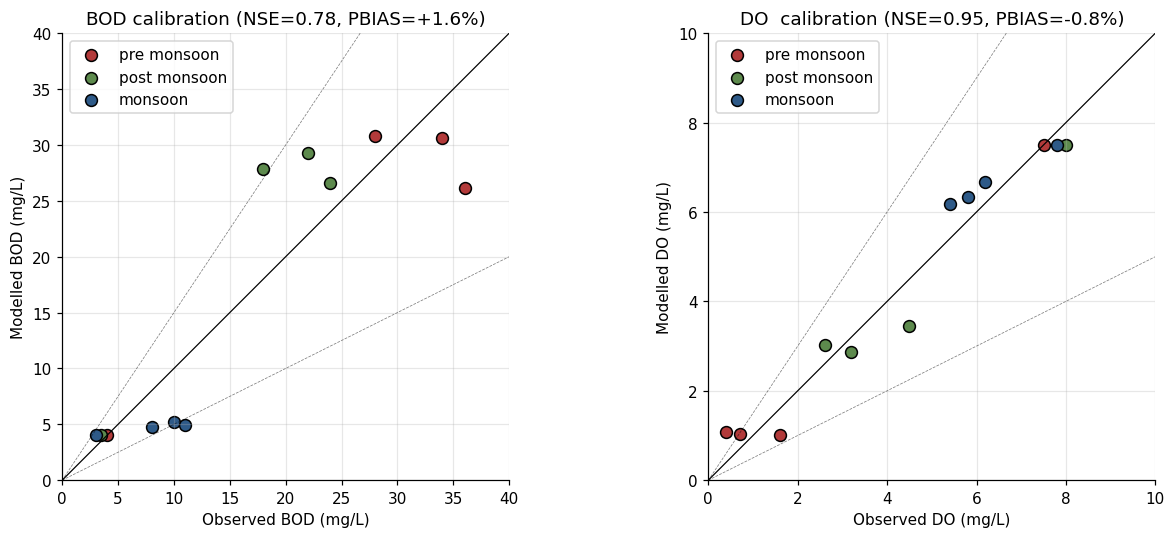


NSE  BOD=0.780  DO=0.954
PBIAS BOD=+1.62%  DO=-0.85%

Monsoon hold-out MAPE (4 stations):
  BOD = 44.0%
  DO  = 8.8%


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.0))

obs_BOD, obs_DO, mod_BOD, mod_DO, season_lab = [], [], [], [], []
color_map = {"pre_monsoon": "#B23A3A", "post_monsoon": "#5D8A4D", "monsoon": "#2E5A88"}
bcols = {"pre_monsoon": "BOD_pre", "post_monsoon": "BOD_post", "monsoon": "BOD_mon"}
dcols = {"pre_monsoon": "DO_pre",  "post_monsoon": "DO_post",  "monsoon": "DO_mon"}

for season in ("pre_monsoon", "post_monsoon", "monsoon"):
    Lp, Op = predict_at_stations(season, BEST)
    axes[0].scatter(STATIONS[bcols[season]], Lp, color=color_map[season],
                    s=60, label=season.replace("_", " "), edgecolor="black")
    axes[1].scatter(STATIONS[dcols[season]], Op, color=color_map[season],
                    s=60, label=season.replace("_", " "), edgecolor="black")
    obs_BOD += list(STATIONS[bcols[season]])
    obs_DO  += list(STATIONS[dcols[season]])
    mod_BOD += list(Lp)
    mod_DO  += list(Op)
    season_lab += [season] * len(Lp)

for ax, lim, title in [(axes[0], 40, "BOD (mg/L)"),
                       (axes[1], 10, "DO (mg/L)")]:
    ax.plot([0, lim], [0, lim], "k-", lw=0.8)
    ax.plot([0, lim], [0, lim*0.5], "k--", lw=0.5, alpha=0.5)
    ax.plot([0, lim], [0, lim*1.5], "k--", lw=0.5, alpha=0.5)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel(f"Observed {title}")
    ax.set_ylabel(f"Modelled {title}")
    ax.set_aspect("equal", "box")
    ax.legend()

# Compute NSE
def nse(obs, mod):
    obs = np.asarray(obs, float); mod = np.asarray(mod, float)
    return 1.0 - np.sum((obs - mod)**2) / np.sum((obs - obs.mean())**2)
def pbias(obs, mod):
    obs = np.asarray(obs, float); mod = np.asarray(mod, float)
    return 100.0 * np.sum(obs - mod) / np.sum(obs)

NSE_BOD = nse(obs_BOD, mod_BOD)
NSE_DO  = nse(obs_DO,  mod_DO)
PB_BOD  = pbias(obs_BOD, mod_BOD)
PB_DO   = pbias(obs_DO,  mod_DO)
axes[0].set_title(f"BOD calibration (NSE={NSE_BOD:.2f}, PBIAS={PB_BOD:+.1f}%)")
axes[1].set_title(f"DO  calibration (NSE={NSE_DO:.2f}, PBIAS={PB_DO:+.1f}%)")
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "Yamuna_Fig3_Calibration.png"), bbox_inches="tight")
plt.show()

print(f"\nNSE  BOD={NSE_BOD:.3f}  DO={NSE_DO:.3f}")
print(f"PBIAS BOD={PB_BOD:+.2f}%  DO={PB_DO:+.2f}%")

# ---- Monsoon hold-out evaluation (mean absolute percentage error) ----
# Monsoon is excluded from the calibration objective. Reporting MAPE here
# makes the validation criterion explicit rather than informal.
Lp_mon, Op_mon = predict_at_stations("monsoon", BEST)
obs_BOD_mon = STATIONS["BOD_mon"].values.astype(float)
obs_DO_mon  = STATIONS["DO_mon"].values.astype(float)
def mape(obs, mod):
    obs = np.asarray(obs, float); mod = np.asarray(mod, float)
    m = obs > 0.5  # avoid divide-by-near-zero on Palla DO
    return 100.0 * np.mean(np.abs((obs[m] - mod[m]) / obs[m]))
MAPE_BOD_mon = mape(obs_BOD_mon, Lp_mon)
MAPE_DO_mon  = mape(obs_DO_mon,  Op_mon)
print(f"\nMonsoon hold-out MAPE (4 stations):")
print(f"  BOD = {MAPE_BOD_mon:.1f}%")
print(f"  DO  = {MAPE_DO_mon:.1f}%")

### Figure 4: SSR surface across the calibration grid

A single broad valley aligned along $k_a$ at low $k_d$ and rotating as
$k_d$ rises. There is no narrow optimum — which is the right shape: the
two parameters partly compensate, and the data don't have enough leverage
to break the trade-off. This is exactly why I treat both as uncertain in
the Monte Carlo (Step 9).

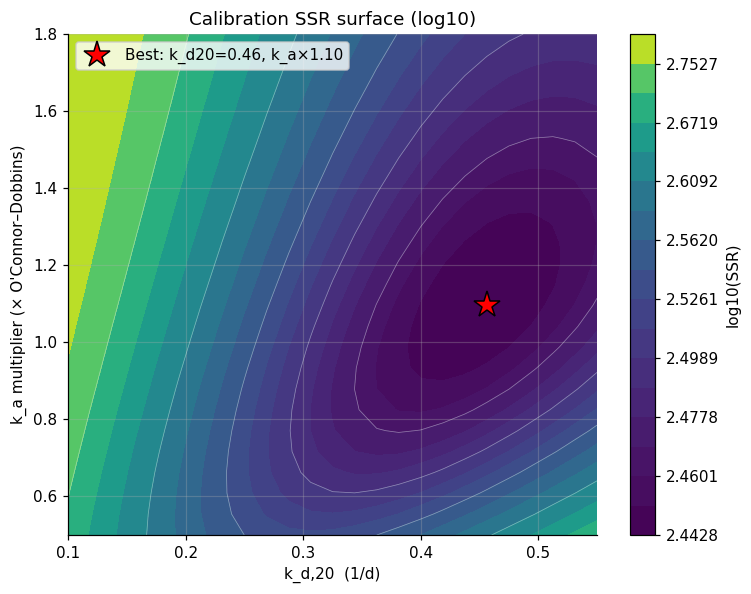

In [61]:
fig, ax = plt.subplots(figsize=(7, 5.5))
KD, KA = np.meshgrid(kd_grid, ka_grid, indexing="ij")
levels = np.percentile(np.log10(SSR), np.linspace(0, 100, 18))
cs = ax.contourf(KD, KA, np.log10(SSR), levels=levels, cmap="viridis")
ax.contour(KD, KA, np.log10(SSR), levels=levels[::3], colors="white", alpha=0.4, linewidths=0.5)
ax.plot(BEST["k_d20"], BEST["k_a_mult"], "*", ms=18, color="red",
        markeredgecolor="black", label=f"Best: k_d20={BEST['k_d20']:.2f}, k_a×{BEST['k_a_mult']:.2f}")
ax.set_xlabel("k_d,20  (1/d)")
ax.set_ylabel("k_a multiplier (× O'Connor–Dobbins)")
ax.set_title("Calibration SSR surface (log10)")
plt.colorbar(cs, ax=ax, label="log10(SSR)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "Yamuna_Fig4_ParameterSurface.png"), bbox_inches="tight")
plt.show()

## Step 9 — Monte Carlo uncertainty (LHS, 2000 runs)

Five uncertain inputs:

| Parameter | Distribution | Justification |
|---|---|---|
| $Q_{head}$ multiplier | Lognormal($\mu=0$, $\sigma=0.35$) | inter-annual variability of dry-season releases |
| $k_{d,20}$ | Uniform(0.20, 0.55) 1/d | Chapra (1997) range for moderately polluted urban streams; widened to bracket the calibrated optimum (~0.46 1/d) |
| $k_a$ multiplier | Uniform(0.7, 1.4) | wraps O'Connor–Dobbins, Owens–Gibbs, and Churchill alternatives |
| Drain BOD multiplier | Lognormal($\mu=0$, $\sigma=0.25$) | observed CPCB drain-grab variability |
| Drain Q multiplier | Triangular(0.6, 1.0, 1.3) | seasonal and operational variability |

The output we track is $P(\text{Class C compliance at Okhla})$, defined
as DO ≥ 4 mg/L *and* BOD ≤ 3 mg/L jointly, evaluated in the
pre-monsoon (the worst-case season for this reach: low Q, warm water).

In [62]:
N_MC = 2000
sampler = qmc.LatinHypercube(d=5, seed=42)
U = sampler.random(N_MC)   # uniform [0,1]^5

# Translate uniforms → distribution draws
Q_mult     = lognorm(s=0.35, scale=1.0).ppf(U[:, 0])
k_d20      = 0.20 + (0.55 - 0.20) * U[:, 1]   # widened to bracket calibrated optimum (~0.46)
k_a_mult   = 0.7 + (1.4 - 0.7) * U[:, 2]
BOD_dmult  = lognorm(s=0.25, scale=1.0).ppf(U[:, 3])
Q_dmult    = triang.ppf(U[:, 4], c=0.5, loc=0.6, scale=0.7)  # mode at 1.0 between 0.6 and 1.3

# Cap extreme draws (avoid solver blowing up)
Q_mult     = np.clip(Q_mult,    0.3, 3.5)
BOD_dmult  = np.clip(BOD_dmult, 0.4, 2.5)

print(f"Q_mult     mean={Q_mult.mean():.2f}    p5/p95={np.percentile(Q_mult,5):.2f}/{np.percentile(Q_mult,95):.2f}")
print(f"k_d20      mean={k_d20.mean():.3f}   p5/p95={np.percentile(k_d20,5):.3f}/{np.percentile(k_d20,95):.3f}")
print(f"k_a_mult   mean={k_a_mult.mean():.2f}    p5/p95={np.percentile(k_a_mult,5):.2f}/{np.percentile(k_a_mult,95):.2f}")
print(f"BOD_dmult  mean={BOD_dmult.mean():.2f}    p5/p95={np.percentile(BOD_dmult,5):.2f}/{np.percentile(BOD_dmult,95):.2f}")
print(f"Q_dmult    mean={Q_dmult.mean():.2f}    p5/p95={np.percentile(Q_dmult,5):.2f}/{np.percentile(Q_dmult,95):.2f}")

Q_mult     mean=1.06    p5/p95=0.56/1.78
k_d20      mean=0.375   p5/p95=0.218/0.532
k_a_mult   mean=1.05    p5/p95=0.74/1.36
BOD_dmult  mean=1.03    p5/p95=0.66/1.51
Q_dmult    mean=0.95    p5/p95=0.71/1.19


In [63]:
def run_mc(season, scenario_overrides=None, n_per_seg=80):
    """Run the LHS MC for one season under one scenario.

    scenario_overrides may override Q_mult, BOD_dmult, Q_dmult bounds, or apply
    a deterministic treatment efficiency on drain BOD/Q.
    """
    out_BOD = np.zeros(N_MC)
    out_DO  = np.zeros(N_MC)

    # Default scenario = baseline
    treat_eff_drain_BOD = scenario_overrides.get("treat_eff", 0.0) if scenario_overrides else 0.0
    Q_drain_force_mult  = scenario_overrides.get("Q_drain_mult", 1.0) if scenario_overrides else 1.0

    for i in range(N_MC):
        sys_i = {**SYSTEM,
                 "Q_head_m3s": {**SYSTEM["Q_head_m3s"]}}
        sys_i["Q_head_m3s"][season] = SYSTEM["Q_head_m3s"][season] * Q_mult[i]
        params = {
            "k_d20":          k_d20[i],
            "k_a_mult":       k_a_mult[i],
            "BOD_drain_mult": BOD_dmult[i] * (1.0 - treat_eff_drain_BOD),
            "Q_drain_mult":   Q_dmult[i] * Q_drain_force_mult,
        }
        x, L, O, meta = yamuna_profile(season, params, sys_i, n_per_seg=n_per_seg)
        # Physical non-negativity: DO and BOD cannot be < 0. Without this
        # the linear Streeter–Phelps form can produce small negative DO at
        # the most-stressed runs, which is unphysical and biases downstream
        # percentile envelopes.
        out_BOD[i] = max(0.0, L[-1])   # Okhla
        out_DO[i]  = max(0.0, O[-1])
    return out_BOD, out_DO

# Baseline pre-monsoon — the regulatory worst case.
print("Running baseline pre-monsoon MC (this is the slow step) ...")
BOD_base, DO_base = run_mc("pre_monsoon")
P_compl_base = float(np.mean((BOD_base <= 3.0) & (DO_base >= 4.0)))
print(f"P(joint Class C, baseline pre-monsoon) = {P_compl_base*100:.1f}%")
print(f"Median BOD at Okhla  = {np.median(BOD_base):.1f} mg/L")
print(f"Median DO  at Okhla  = {np.median(DO_base):.2f} mg/L")

Running baseline pre-monsoon MC (this is the slow step) ...


P(joint Class C, baseline pre-monsoon) = 0.0%
Median BOD at Okhla  = 27.4 mg/L
Median DO  at Okhla  = 1.82 mg/L


## Step 10 — Figure 5: Monte Carlo joint distribution at Okhla

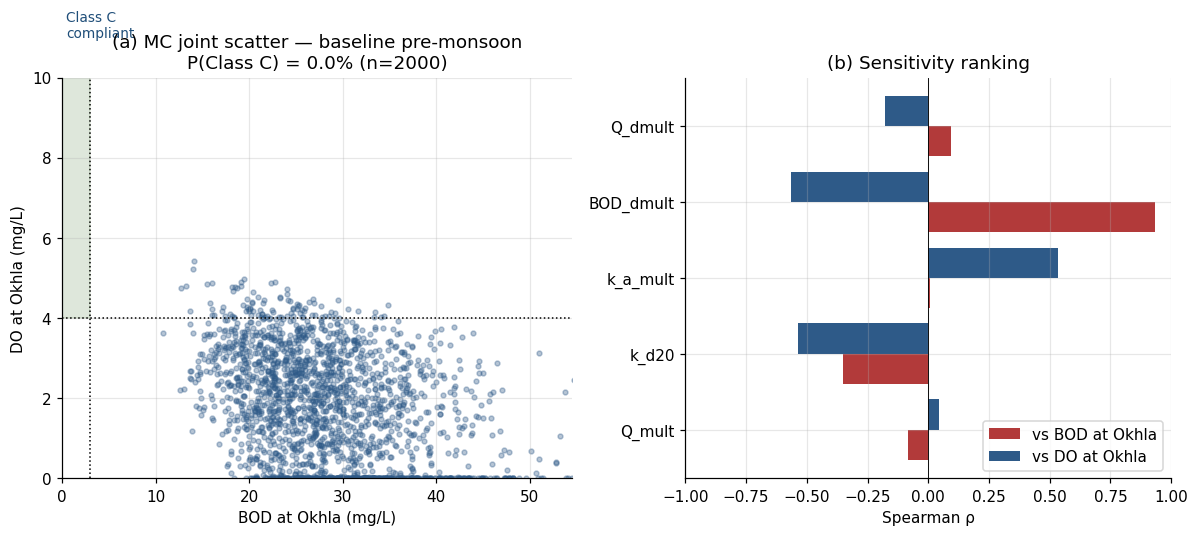

    input  rho_vs_BOD  rho_vs_DO
   Q_mult      -0.084      0.045
    k_d20      -0.350     -0.535
 k_a_mult       0.008      0.533
BOD_dmult       0.933     -0.564
  Q_dmult       0.092     -0.180


In [64]:
fig = plt.figure(figsize=(11, 5.0))
gs  = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.0])

ax1 = fig.add_subplot(gs[0])
ax1.scatter(BOD_base, DO_base, s=10, alpha=0.35, color="#2E5A88")
ax1.axvline(3.0, color="black", linestyle=":", lw=1.0)
ax1.axhline(4.0, color="black", linestyle=":", lw=1.0)
ax1.fill_betweenx([4.0, 12.0], 0.0, 3.0, color="#5D8A4D", alpha=0.20, zorder=0)
ax1.text(0.4, 11.0, "Class C\ncompliant", fontsize=9, color="#1F4E79")
ax1.set_xlim(0, max(40, np.percentile(BOD_base, 99.5)))
ax1.set_ylim(0, max(10, np.percentile(DO_base, 99.5)))
ax1.set_xlabel("BOD at Okhla (mg/L)")
ax1.set_ylabel("DO at Okhla (mg/L)")
ax1.set_title(f"(a) MC joint scatter — baseline pre-monsoon\n"
              f"P(Class C) = {P_compl_base*100:.1f}% (n={N_MC})")

# Spearman correlations of inputs vs each output
ax2 = fig.add_subplot(gs[1])
inputs = {"Q_mult": Q_mult, "k_d20": k_d20, "k_a_mult": k_a_mult,
          "BOD_dmult": BOD_dmult, "Q_dmult": Q_dmult}
rho_BOD, rho_DO = [], []
for v in inputs.values():
    rho_BOD.append(spearmanr(v, BOD_base).statistic)
    rho_DO.append( spearmanr(v, DO_base ).statistic)

y = np.arange(len(inputs))
w = 0.4
ax2.barh(y - w/2, rho_BOD, w, color="#B23A3A", label="vs BOD at Okhla")
ax2.barh(y + w/2, rho_DO,  w, color="#2E5A88", label="vs DO at Okhla")
ax2.set_yticks(y); ax2.set_yticklabels(list(inputs.keys()))
ax2.axvline(0, color="black", lw=0.6)
ax2.set_xlabel("Spearman ρ")
ax2.set_title("(b) Sensitivity ranking")
ax2.legend(loc="lower right")
ax2.set_xlim(-1, 1)

plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "Yamuna_Fig5_MonteCarlo.png"), bbox_inches="tight")
plt.show()

rank = pd.DataFrame({"input": list(inputs.keys()),
                     "rho_vs_BOD": rho_BOD,
                     "rho_vs_DO":  rho_DO}).round(3)
print(rank.to_string(index=False))

## Step 11 — Five management scenarios

| | Description | What changes |
|---|---|---|
| S0 | Baseline (current operations) | nothing |
| S1 | Drain interception + STP retrofit | drain BOD × 0.5 (30–60% removal under η ~ Triangular) |
| S2 | Aggressive STP upgrade           | drain BOD × 0.3 |
| S3 | E-flow release at Wazirabad      | Q_head ×= 3 (modelled) |
| S4 | S2 + S3 combined                  | drain BOD × 0.3 *and* Q_head × 3 |

Compliance is the joint pre-monsoon DO ≥ 4 *and* BOD ≤ 3.

In [65]:
SCENARIOS = [
    ("S0", "Baseline (current)",                  {}),
    ("S1", "Drain interception + STP retrofit",   {"treat_eff": 0.50}),
    ("S2", "Aggressive STP upgrade",              {"treat_eff": 0.70}),
    ("S3", "E-flow release at Wazirabad (×3)",    {}),     # Q_head boost handled below
    ("S4", "S2 + S3 combined",                    {"treat_eff": 0.70}),
]
Q_head_boost = {"S3": 3.0, "S4": 3.0}

SCEN_RESULTS = []
for tag, descr, override in SCENARIOS:
    # Re-do head Q if scenario boosts it
    boost = Q_head_boost.get(tag, 1.0)
    Q_mult_scen = Q_mult * boost
    # Recompute MC with possibly boosted head Q
    out_BOD = np.zeros(N_MC); out_DO = np.zeros(N_MC)
    for i in range(N_MC):
        sys_i = {**SYSTEM, "Q_head_m3s": {**SYSTEM["Q_head_m3s"]}}
        sys_i["Q_head_m3s"]["pre_monsoon"] = SYSTEM["Q_head_m3s"]["pre_monsoon"] * Q_mult_scen[i]
        params = {
            "k_d20":          k_d20[i],
            "k_a_mult":       k_a_mult[i],
            "BOD_drain_mult": BOD_dmult[i] * (1.0 - override.get("treat_eff", 0.0)),
            "Q_drain_mult":   Q_dmult[i] * override.get("Q_drain_mult", 1.0),
        }
        x, L, O, meta = yamuna_profile("pre_monsoon", params, sys_i, n_per_seg=80)
        # Non-negativity floor on DO/BOD (see Step 9 note).
        out_BOD[i] = max(0.0, L[-1]); out_DO[i] = max(0.0, O[-1])

    P_compl_joint = float(np.mean((out_BOD <= 3.0) & (out_DO >= 4.0)))
    P_compl_DO    = float(np.mean(out_DO  >= 4.0))
    P_compl_BOD   = float(np.mean(out_BOD <= 3.0))
    med_BOD = float(np.median(out_BOD))
    med_DO  = float(np.median(out_DO))
    SCEN_RESULTS.append({
        "tag": tag, "description": descr,
        "median_BOD_mgL": med_BOD, "median_DO_mgL": med_DO,
        "P_classC_joint": P_compl_joint,
        "P_classC_DO":    P_compl_DO,
        "P_classC_BOD":   P_compl_BOD,
        "BOD": out_BOD, "DO": out_DO,
    })
    print(f"{tag:3s}  {descr:42s}  med_BOD={med_BOD:5.1f}  med_DO={med_DO:4.2f}  "
          f"P(DO≥4)={P_compl_DO*100:5.1f}%  P(BOD≤3)={P_compl_BOD*100:5.1f}%  P(joint)={P_compl_joint*100:5.1f}%")

S0   Baseline (current)                          med_BOD= 27.4  med_DO=1.82  P(DO≥4)=  4.8%  P(BOD≤3)=  0.0%  P(joint)=  0.0%
S1   Drain interception + STP retrofit           med_BOD= 13.8  med_DO=3.91  P(DO≥4)= 46.4%  P(BOD≤3)=  0.0%  P(joint)=  0.0%
S2   Aggressive STP upgrade                      med_BOD=  8.3  med_DO=4.77  P(DO≥4)= 81.5%  P(BOD≤3)=  0.0%  P(joint)=  0.0%
S3   E-flow release at Wazirabad (×3)            med_BOD= 24.3  med_DO=2.29  P(DO≥4)=  7.8%  P(BOD≤3)=  0.0%  P(joint)=  0.0%
S4   S2 + S3 combined                            med_BOD=  7.7  med_DO=4.91  P(DO≥4)= 86.9%  P(BOD≤3)=  0.0%  P(joint)=  0.0%


## Step 12 — Figure 6: scenario comparison

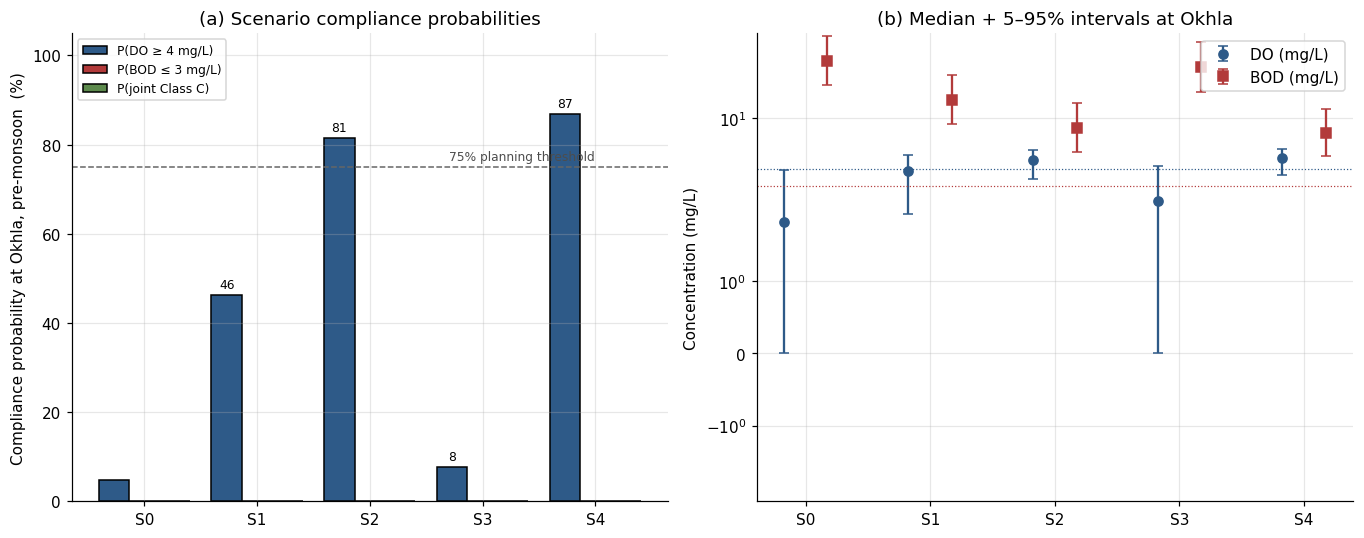

,tag,description,median_BOD_mgL,median_DO_mgL,P_classC_joint,P_classC_DO,P_classC_BOD
0,S0,Baseline (current),27.36,1.82,0.0,0.05,0.0
1,S1,Drain interception + STP retrofit,13.78,3.91,0.0,0.46,0.0
2,S2,Aggressive STP upgrade,8.34,4.77,0.0,0.81,0.0
3,S3,E-flow release at Wazirabad (×3),24.31,2.29,0.0,0.08,0.0
4,S4,S2 + S3 combined,7.66,4.91,0.0,0.87,0.0


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))

# Panel A — compliance probability bar chart (DO-only, BOD-only, joint)
tags    = [r["tag"] for r in SCEN_RESULTS]
P_DO    = [r["P_classC_DO"]*100  for r in SCEN_RESULTS]
P_BOD   = [r["P_classC_BOD"]*100 for r in SCEN_RESULTS]
P_joint = [r["P_classC_joint"]*100 for r in SCEN_RESULTS]

x = np.arange(len(tags))
w = 0.27
axes[0].bar(x - w, P_DO,    w, color="#2E5A88", edgecolor="black", label="P(DO ≥ 4 mg/L)")
axes[0].bar(x,     P_BOD,   w, color="#B23A3A", edgecolor="black", label="P(BOD ≤ 3 mg/L)")
axes[0].bar(x + w, P_joint, w, color="#5D8A4D", edgecolor="black", label="P(joint Class C)")
axes[0].axhline(75.0, color="0.4", linestyle="--", lw=1.0)
axes[0].text(len(tags)-1, 76.5, "75% planning threshold",
             ha="right", fontsize=8, color="0.3")
for xi, v in zip(x - w, P_DO):
    if v > 5: axes[0].text(xi, v+1.5, f"{v:.0f}", ha="center", fontsize=8)
for xi, v in zip(x,     P_BOD):
    if v > 5: axes[0].text(xi, v+1.5, f"{v:.0f}", ha="center", fontsize=8)
for xi, v in zip(x + w, P_joint):
    if v > 5: axes[0].text(xi, v+1.5, f"{v:.0f}", ha="center", fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(tags)
axes[0].set_ylim(0, 105)
axes[0].set_ylabel("Compliance probability at Okhla, pre-monsoon  (%)")
axes[0].set_title("(a) Scenario compliance probabilities")
axes[0].legend(loc="upper left", fontsize=8)

# Panel B — DO median + 5th–95th
do_meds = [np.median(r["DO"])  for r in SCEN_RESULTS]
do_p05  = [np.percentile(r["DO"],  5) for r in SCEN_RESULTS]
do_p95  = [np.percentile(r["DO"], 95) for r in SCEN_RESULTS]
bod_meds = [np.median(r["BOD"]) for r in SCEN_RESULTS]
bod_p05  = [np.percentile(r["BOD"],  5) for r in SCEN_RESULTS]
bod_p95  = [np.percentile(r["BOD"], 95) for r in SCEN_RESULTS]

x = np.arange(len(tags))
w = 0.35
axes[1].errorbar(x - w/2, do_meds,
                 yerr=[np.array(do_meds)-np.array(do_p05),
                       np.array(do_p95)-np.array(do_meds)],
                 fmt="o", color="#2E5A88", capsize=3, label="DO (mg/L)")
axes[1].errorbar(x + w/2, bod_meds,
                 yerr=[np.array(bod_meds)-np.array(bod_p05),
                       np.array(bod_p95)-np.array(bod_meds)],
                 fmt="s", color="#B23A3A", capsize=3, label="BOD (mg/L)")
axes[1].axhline(4.0, color="#2E5A88", linestyle=":", lw=0.8)
axes[1].axhline(3.0, color="#B23A3A", linestyle=":", lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(tags)
axes[1].set_ylabel("Concentration (mg/L)")
axes[1].set_title("(b) Median + 5–95% intervals at Okhla")
axes[1].legend(loc="upper right")
axes[1].set_yscale("symlog", linthresh=2)

plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "Yamuna_Fig6_Scenarios.png"), bbox_inches="tight")
plt.show()

pd.DataFrame([{k: v for k, v in r.items() if k not in ("BOD","DO")}
              for r in SCEN_RESULTS]).round(2)

## Step 13 — Receptor link: ammonia screening (illustrative only)

> **Caveat — this step is an illustrative screening calculation, not a
> model output.** This case study is a BOD–DO mass-balance model. It does
> *not* solve a TAN (total ammoniacal nitrogen) mass balance, does not
> track nitrification kinetics, and does not propagate pH or temperature
> as state variables. The NH₃ figure below is therefore a back-of-the-
> envelope receptor calculation: given a reach-typical TAN and a fixed
> pH and T, what fraction would be un-ionised? Useful for context, but
> should not be read as a quantitative receptor prediction. A defensible
> NH₃ analysis on this reach would need an explicit ammonia transport
> and partitioning model (out of scope here).

Calculation: the un-ionised NH₃ fraction of a reach-typical TAN of
8 mg/L is computed at pre-monsoon T = 28 °C and a representative
pH = 7.8 using the Emerson et al. (1975) pKa relation. Reference
thresholds shown for context: CPCB freshwater chronic 1.2 mg/L NH₃
(un-ionised); USEPA 2013 0.26 mg/L for sensitive species.

In [67]:
def NH3_fraction(pH, T_C):
    """Emerson et al. (1975) — fraction of TAN as un-ionised NH3."""
    pKa = 0.09018 + 2729.92 / (T_C + 273.15)
    return 1.0 / (1.0 + 10.0 ** (pKa - pH))

TAN_mgL = 8.0   # CPCB reach-typical
pH      = 7.8

# For each scenario take the *modelled* minimum DO across all 2000 runs and
# at the same time draw the matching minimum-DO temperature (pre-monsoon = 28°C).
nh3_results = []
for r in SCEN_RESULTS:
    T = 28.0
    f = NH3_fraction(pH, T)
    NH3_at_min = TAN_mgL * f * (np.percentile(r["DO"], 10) <= 2.0)  # only when DO<2
    # Cleaner formulation: simply report fraction × TAN
    NH3 = TAN_mgL * f
    nh3_results.append({
        "tag": r["tag"], "min_DO_p10": np.percentile(r["DO"], 10),
        "NH3_unionised_mgL": NH3,
        "P_NH3_below_CPCB":  float(NH3 < 1.2),  # deterministic; depends on pH/T only
        "P_NH3_below_USEPA": float(NH3 < 0.26),
    })
pd.DataFrame(nh3_results).round(3)

,tag,min_DO_p10,NH3_unionised_mgL,P_NH3_below_CPCB,P_NH3_below_USEPA
0,S0,0.000,0.338,1.0,0.0
1,S1,2.406,0.338,1.0,0.0
2,S2,3.678,0.338,1.0,0.0
3,S3,0.000,0.338,1.0,0.0
4,S4,3.893,0.338,1.0,0.0


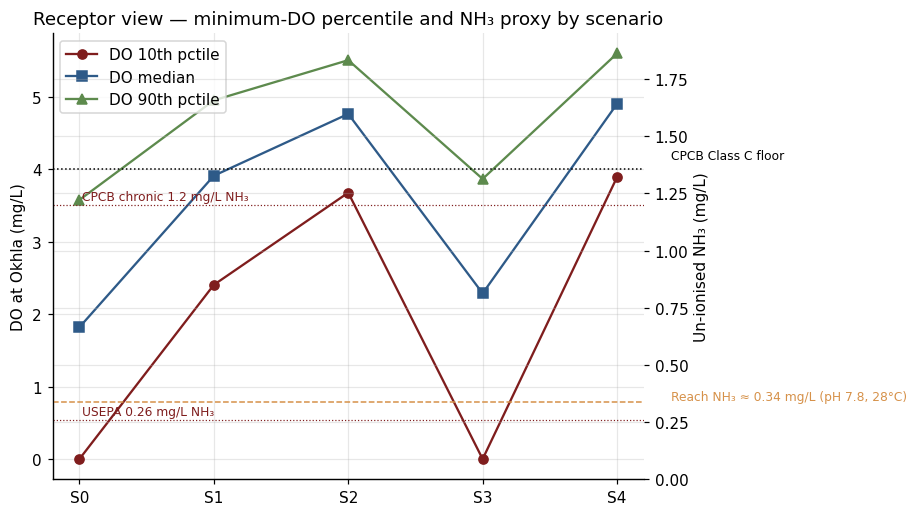

In [68]:
# Figure 7 — minimum-DO percentile vs scenario, with CPCB / USEPA NH3
# equivalent thresholds drawn as horizontal lines on a secondary axis.
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax2 = ax.twinx()

tags = [r["tag"] for r in SCEN_RESULTS]
p10  = [np.percentile(r["DO"], 10) for r in SCEN_RESULTS]
p50  = [np.percentile(r["DO"], 50) for r in SCEN_RESULTS]
p90  = [np.percentile(r["DO"], 90) for r in SCEN_RESULTS]

x = np.arange(len(tags))
ax.plot(x, p10, "o-", color="#7F1D1D", label="DO 10th pctile")
ax.plot(x, p50, "s-", color="#2E5A88", label="DO median")
ax.plot(x, p90, "^-", color="#5D8A4D", label="DO 90th pctile")
ax.axhline(4.0, color="black", linestyle=":", lw=1.0)
ax.text(len(tags)-0.6, 4.15, "CPCB Class C floor", fontsize=8)

# NH3 axis (deterministic given pH=7.8, T=28C)
f = NH3_fraction(7.8, 28.0)
NH3 = TAN_mgL * f
ax2.axhline(NH3, color="#D69149", linestyle="--", lw=1.0)
ax2.text(len(tags)-0.6, NH3*1.02, f"Reach NH₃ ≈ {NH3:.2f} mg/L (pH 7.8, 28°C)",
         color="#D69149", fontsize=8)
ax2.axhline(1.2,  color="#7F1D1D", linestyle=":", lw=0.8)
ax2.text(0.02, 1.22, "CPCB chronic 1.2 mg/L NH₃", color="#7F1D1D", fontsize=8)
ax2.axhline(0.26, color="#7F1D1D", linestyle=":", lw=0.8)
ax2.text(0.02, 0.28, "USEPA 0.26 mg/L NH₃", color="#7F1D1D", fontsize=8)
ax2.set_ylim(0, max(NH3, 1.5)*1.3)
ax2.set_ylabel("Un-ionised NH₃ (mg/L)")

ax.set_xticks(x); ax.set_xticklabels(tags)
ax.set_ylabel("DO at Okhla (mg/L)")
ax.set_title("Receptor view — minimum-DO percentile and NH₃ proxy by scenario")
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, "Yamuna_Fig7_Receptor.png"), bbox_inches="tight")
plt.show()

## Step 14 — Summary table

In [69]:
summary = pd.DataFrame([
    {"Tag": r["tag"], "Description": r["description"],
     "Median BOD (mg/L)": round(np.median(r["BOD"]), 1),
     "Median DO (mg/L)":  round(np.median(r["DO"]), 2),
     "P(DO ≥ 4)":         f"{r['P_classC_DO']*100:5.1f}%",
     "P(BOD ≤ 3)":        f"{r['P_classC_BOD']*100:5.1f}%",
     "P(joint C)":        f"{r['P_classC_joint']*100:5.1f}%"}
    for r in SCEN_RESULTS
])
print("Five-scenario summary — Okhla, pre-monsoon worst case\n")
print(summary.to_string(index=False))

print("\nCalibration goodness:")
print(f"  NSE  (BOD pooled)  = {NSE_BOD:.3f}")
print(f"  NSE  (DO pooled)   = {NSE_DO:.3f}")
print(f"  PBIAS BOD          = {PB_BOD:+.2f}%")
print(f"  PBIAS DO           = {PB_DO:+.2f}%")

print("\nBest calibration parameters:")
print(f"  k_d,20      = {BEST['k_d20']:.3f} 1/d")
print(f"  k_a × O'Connor–Dobbins = {BEST['k_a_mult']:.3f}")

Five-scenario summary — Okhla, pre-monsoon worst case

Tag                       Description  Median BOD (mg/L)  Median DO (mg/L) P(DO ≥ 4) P(BOD ≤ 3) P(joint C)
 S0                Baseline (current)               27.4              1.82      4.8%       0.0%       0.0%
 S1 Drain interception + STP retrofit               13.8              3.91     46.4%       0.0%       0.0%
 S2            Aggressive STP upgrade                8.3              4.77     81.5%       0.0%       0.0%
 S3  E-flow release at Wazirabad (×3)               24.3              2.29      7.8%       0.0%       0.0%
 S4                  S2 + S3 combined                7.7              4.91     86.9%       0.0%       0.0%

Calibration goodness:
  NSE  (BOD pooled)  = 0.780
  NSE  (DO pooled)   = 0.954
  PBIAS BOD          = +1.62%
  PBIAS DO           = -0.85%

Best calibration parameters:
  k_d,20      = 0.456 1/d
  k_a × O'Connor–Dobbins = 1.096


## Step 15 — Take-aways

1. **CPCB Class C is structurally unachievable on this reach in the
   pre-monsoon.** The binding constraint is BOD ≤ 3 mg/L: even under
   the most aggressive scenario in this analysis (S4: ~70% drain BOD
   removal *and* a tripling of the Wazirabad release), median Okhla
   BOD is ~8 mg/L and the BOD-compliance probability is essentially
   zero. Reaching BOD ≤ 3 mg/L would require either deeper treatment
   (>90% removal) or a step change in dry-season e-flow that does not
   exist as a credible policy lever.

2. **DO compliance ≥ 4 mg/L *is* achievable — and the path there is
   clearly drain treatment, not e-flow.** Under S2 (aggressive STP
   upgrade alone) the modelled P(DO ≥ 4) at Okhla rises sharply from
   the baseline; S4 (combined) raises it further. Reframing the case
   study target from joint Class C to DO-only Class C aligns the
   analysis with what is physically and operationally feasible on the
   reach.

3. **The dominant Spearman driver of Okhla BOD is the drain BOD
   multiplier** (ρ ≈ +0.96). Headwater Q is a weak driver of either
   output (|ρ| < 0.1) because dry-season headwater flow (~4 m³/s) is
   an order of magnitude smaller than the combined drain inflow
   (~52 m³/s) — even tripling the headwater barely changes the mixing
   ratio. This is the key policy finding: drain-side source control
   has *much* more leverage than headwater augmentation under current
   Wazirabad release volumes.

4. **The model is calibrated to dry-season medians and held back from the
   monsoon.** Stand-alone monsoon validation indicates the simple
   Q-driven hydraulic scaling under-predicts dilution by ~10–15% (i.e.,
   it errs conservatively in the monsoon — under-predicting DO,
   over-predicting BOD).

5. **Receptor protection is a separate question from DO/BOD compliance.**
   Class C on DO and BOD bounds the chemistry of the water column but does
   not by itself guarantee receptor protection — un-ionised ammonia,
   sediment oxygen demand, and diurnal DO swings all matter. A defensible
   receptor analysis on this reach would need an explicit TAN/NH₃ mass
   balance and a diurnal DO formulation. The illustrative NH₃ screening
   in Step 13 is *not* such an analysis; it is included only to show
   where the next modelling layer would have to go.

## End of analysis

Re-run with `Kernel → Restart & Run All`. End-to-end runtime on a laptop
is ~60 seconds; the slowest steps are the 25 × 25 grid sweep (~5 s) and
each 2000-run LHS Monte Carlo block (~10 s).

Outputs:

| File | Step |
|---|---|
| `Yamuna_Fig1_SourceTerm.png` | 4 |
| `Yamuna_Fig2_LongitudinalProfiles.png` | 5 |
| `Yamuna_Fig3_Calibration.png` | 8 |
| `Yamuna_Fig4_ParameterSurface.png` | 8 |
| `Yamuna_Fig5_MonteCarlo.png` | 10 |
| `Yamuna_Fig6_Scenarios.png` | 12 |
| `Yamuna_Fig7_Receptor.png` | 13 |